We cluster the MOSAIKS features using KNN and cosine distance.

In [1]:
import sys
sys.setrecursionlimit(100000) 

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

import glob
import random

from scipy.cluster.vq import kmeans, whiten, vq
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from matplotlib import pyplot as plt
from scipy.spatial import cKDTree

seed = 42
random.seed = seed
subset = 100

We read all the MOSAIK features and concatenate into one big dataframe

In [3]:
files = glob.glob("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/city_embeddings_cropped/*.parquet")

mosaik_features = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)

In [4]:
mosaik_features.columns

Index(['lon', 'lat', 'shapeGroup', 'adm2_shapeID_geoBoundaries',
       'adm1_shapeID_geoBoundaries', 'X_0', 'X_1', 'X_2', 'X_3', 'X_4',
       ...
       'X_3990', 'X_3991', 'X_3992', 'X_3993', 'X_3994', 'X_3995', 'X_3996',
       'X_3997', 'X_3998', 'X_3999'],
      dtype='object', length=4005)

In [5]:
mosaik_features.head

<bound method NDFrame.head of            lon     lat shapeGroup adm2_shapeID_geoBoundaries  \
0      140.115  35.655        JPN    22064153B16459031557594   
1      139.715  35.605        JPN    22064153B77106068491412   
2      139.445  35.625        JPN     22064153B5719123813817   
3      139.405  35.655        JPN    22064153B74315697961644   
4      139.615  35.795        JPN    22064153B26432964343600   
...        ...     ...        ...                        ...   
84256    0.055  51.495       None                       None   
84257   -0.395  51.535        GBR     9080712B45194275403121   
84258    0.065  51.485        GBR     9080712B64588414247228   
84259   -0.505  51.565        GBR     9080712B36857766137746   
84260   -0.295  51.495        GBR     9080712B85959270461063   

      adm1_shapeID_geoBoundaries       X_0       X_1       X_2       X_3  \
0         47310658B1351727290704  0.329524  0.620482  0.179135  0.164759   
1          47310658B199342310790  0.391317  0.799

In [6]:
mosaik_features.shape

(84261, 4005)

In [7]:
mosaik_features = mosaik_features.iloc[random.sample(range(1, len(mosaik_features)), subset)]

#mosaik_features = mosaik_features.groupby('continent').apply(lambda x: x.sample(subset,random_state=seed))

Check for unhelpful elements

In [8]:
data = mosaik_features.iloc[:, 5:]

# Check for non-finite values
print("NaNs per column:\n", data.isna().sum())
print("\nInf values:", (~data.apply(lambda x: x.map(np.isfinite))).sum().sum())

# Check for all-zero rows (cosine distance is undefined for zero vectors)
zero_rows = (data == 0).all(axis=1)
print(f"\nAll-zero rows: {zero_rows.sum()}")

# Quick summary
print("\nShape:", data.shape)
print(data.describe())

NaNs per column:
 X_0       0
X_1       0
X_2       0
X_3       0
X_4       0
         ..
X_3995    0
X_3996    0
X_3997    0
X_3998    0
X_3999    0
Length: 4000, dtype: int64

Inf values: 0

All-zero rows: 0

Shape: (100, 4000)
              X_0         X_1         X_2         X_3           X_4  \
count  100.000000  100.000000  100.000000  100.000000  1.000000e+02   
mean     0.207501    0.445990    0.132983    0.139381  3.138149e-01   
std      0.114947    0.229079    0.077564    0.126105  1.635223e-01   
min      0.000200    0.000000    0.008392    0.000000  9.697000e-07   
25%      0.118802    0.306074    0.075499    0.049592  1.764630e-01   
50%      0.191513    0.439421    0.123777    0.107436  3.112417e-01   
75%      0.264541    0.549766    0.181671    0.184938  3.957532e-01   
max      0.595811    1.290526    0.381273    0.607289  8.423997e-01   

              X_5         X_6         X_7         X_8         X_9  ...  \
count  100.000000  100.000000  100.000000  100.000000  1

Remove unhelpful elements (can't do cosine with 0s)

In [9]:
norms = np.linalg.norm(data.values, axis=1)

# Identify and inspect the problem rows
zero_norm_rows = mosaik_features[norms < 1e-10]
print("Zero-norm rows:")
print(zero_norm_rows)

# Filter them out
data_clean = data[norms >= 1e-10]
print(f"Removed {(norms < 1e-10).sum()} rows, {len(data_clean)} remaining")

Zero-norm rows:
Empty DataFrame
Columns: [lon, lat, shapeGroup, adm2_shapeID_geoBoundaries, adm1_shapeID_geoBoundaries, X_0, X_1, X_2, X_3, X_4, X_5, X_6, X_7, X_8, X_9, X_10, X_11, X_12, X_13, X_14, X_15, X_16, X_17, X_18, X_19, X_20, X_21, X_22, X_23, X_24, X_25, X_26, X_27, X_28, X_29, X_30, X_31, X_32, X_33, X_34, X_35, X_36, X_37, X_38, X_39, X_40, X_41, X_42, X_43, X_44, X_45, X_46, X_47, X_48, X_49, X_50, X_51, X_52, X_53, X_54, X_55, X_56, X_57, X_58, X_59, X_60, X_61, X_62, X_63, X_64, X_65, X_66, X_67, X_68, X_69, X_70, X_71, X_72, X_73, X_74, X_75, X_76, X_77, X_78, X_79, X_80, X_81, X_82, X_83, X_84, X_85, X_86, X_87, X_88, X_89, X_90, X_91, X_92, X_93, X_94, ...]
Index: []

[0 rows x 4005 columns]
Removed 0 rows, 100 remaining


Cosine distance for hierarchical clusters

In [10]:
z = linkage(data_clean.values, metric='cosine')

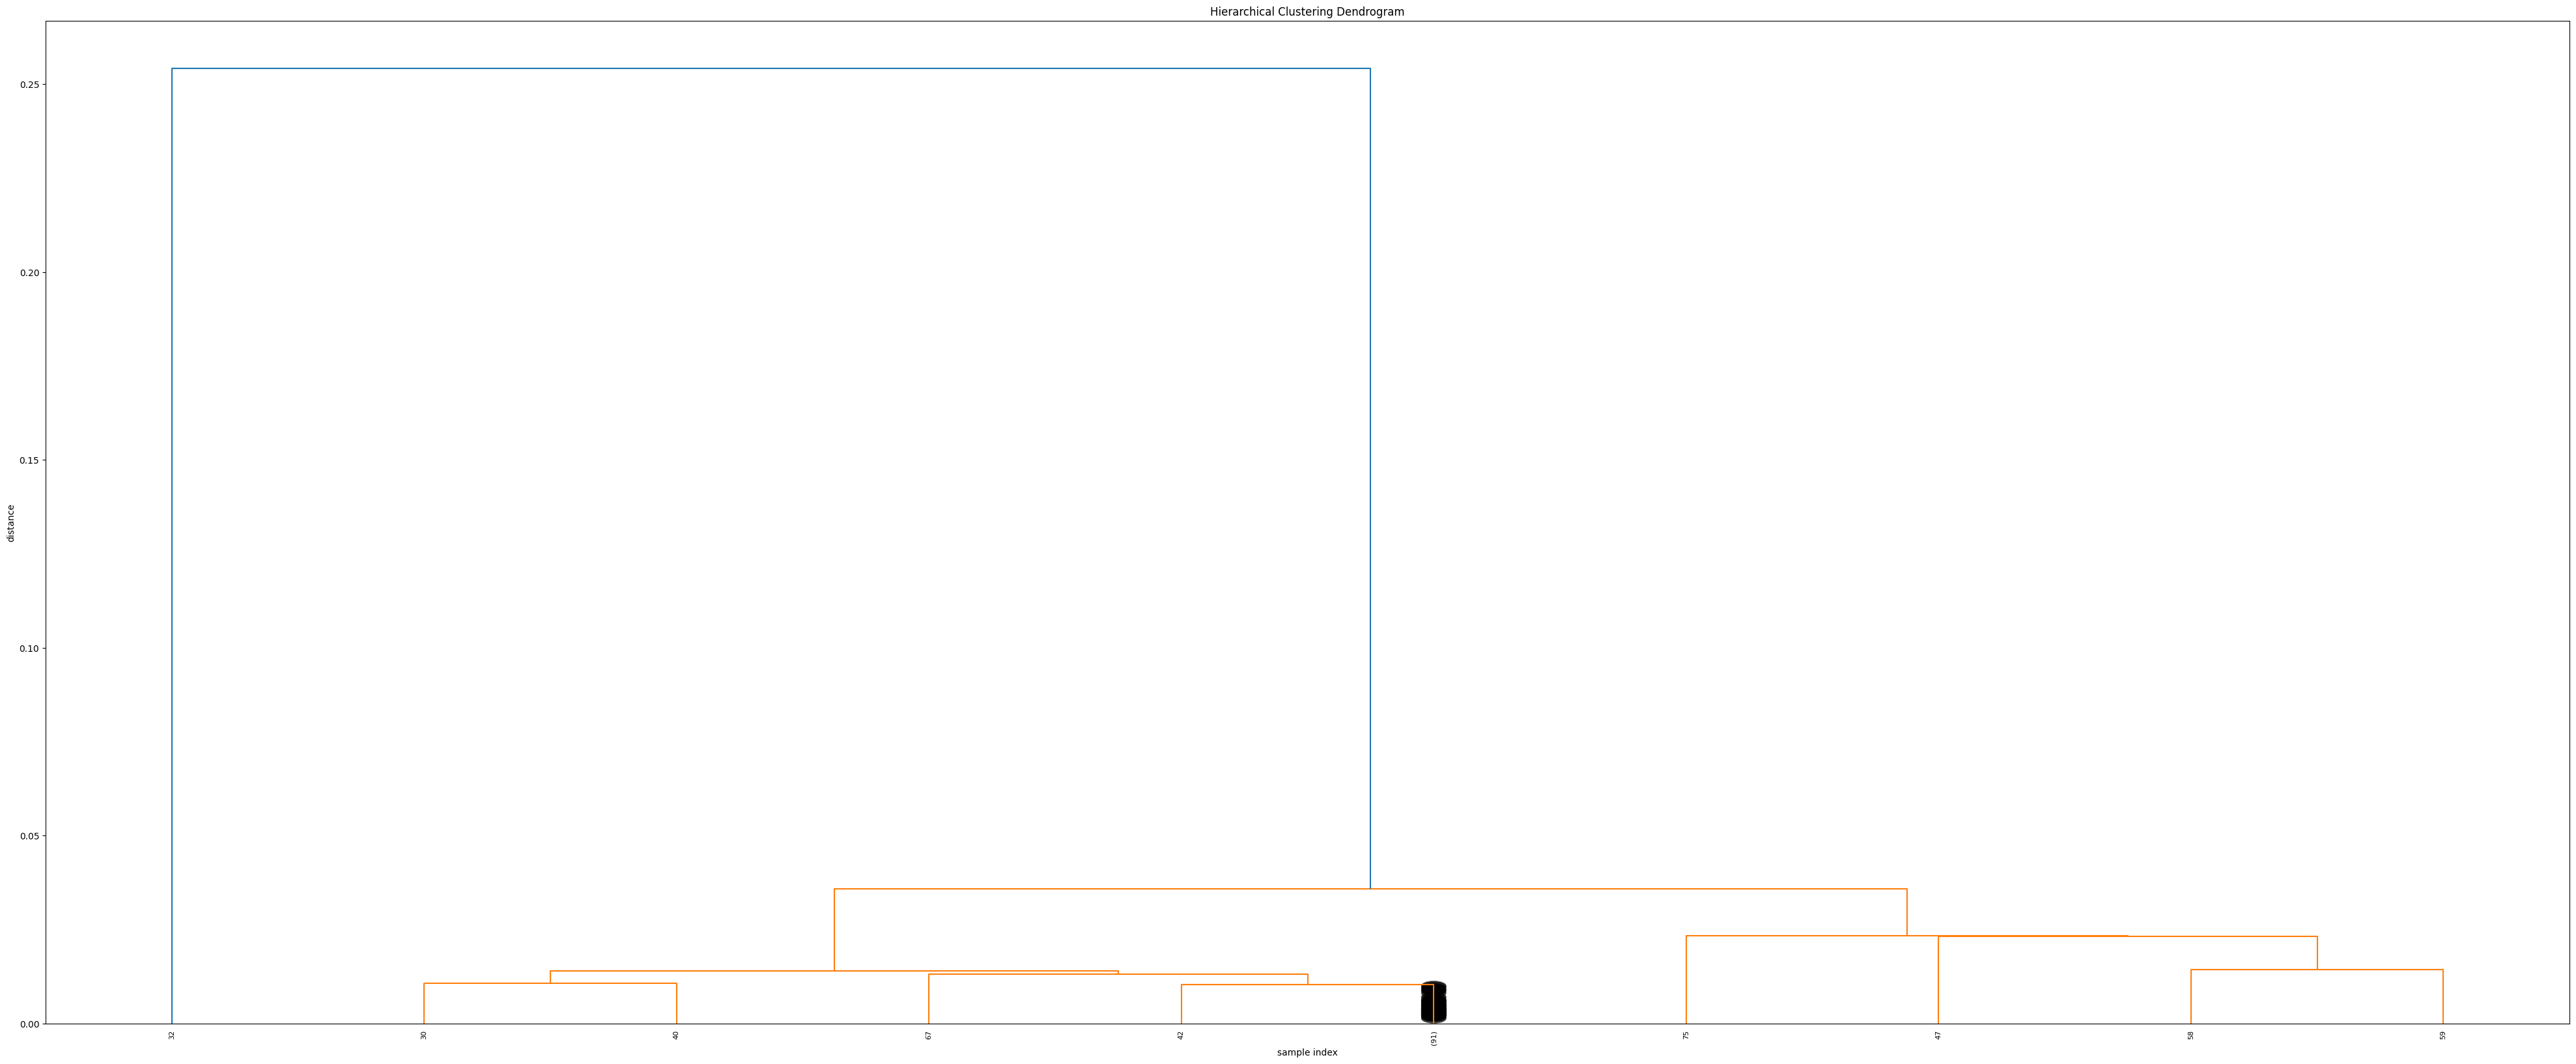

In [11]:
# calculate full dendrogram
plt.figure(figsize=(50, 20))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    truncate_mode='lastp',  # show only the last p merged clusters
    p=10,                   # adjust this number to taste
    show_contracted=True,   # shows a triangle for contracted branches
)
plt.show()

Look at dendogram to decide a threshold for distance. Claude generated code to link back to original dataframe.

In [12]:
# or you can use max cluster to pick the biggest ones
labels = fcluster(z, t=10, criterion='maxclust')
#labels = fcluster(z, t=0.1, criterion='distance')

# --- 2. Build a labeled Series using the cleaned data's index ---
cluster_series = pd.Series(labels, index=data_clean.index, name='cluster')

# --- 3. Join back to the original dataframe ---
mosaik_cluster_labeled = mosaik_features.join(cluster_series)

# Rows that were dropped (zero-norm) will have NaN for cluster
print(mosaik_cluster_labeled['cluster'].value_counts(dropna=False))
print(mosaik_cluster_labeled.shape)

cluster
3     91
1      1
10     1
2      1
4      1
8      1
6      1
7      1
5      1
9      1
Name: count, dtype: int64
(100, 4006)


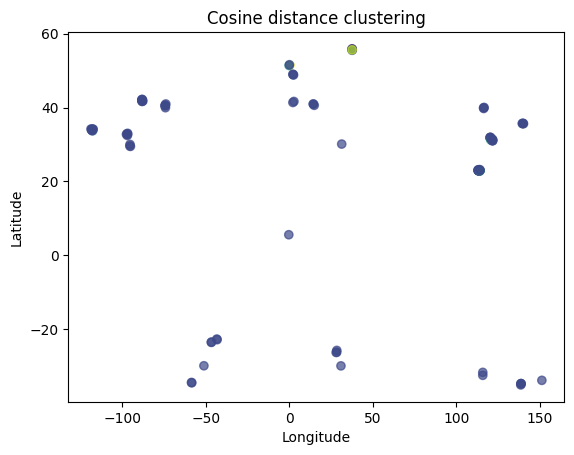

In [13]:
plt.scatter(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat'], c=mosaik_cluster_labeled['cluster'], alpha=0.7)
plt.title("Cosine distance clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Export results

In [14]:
mosaik_cluster_labeled.to_csv("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_cosine_10.csv", index=False)

In [15]:
gdf = gpd.GeoDataFrame(
    mosaik_cluster_labeled['cluster'], 
    geometry=gpd.points_from_xy(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat']),
    crs="EPSG:4326"
)

#gdf.to_file("/data-store/iplant/home/thunr/analyses/clusters_cosine.geojson", driver='GeoJSON')

gdf.to_file("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_cosine_10.geojson", driver='GeoJSON')

Now we do KNN

Loop through multiple values of K to find best one. We use log space because we'd like to search a larger number of clusters at some point.

In [16]:
data_whitened = whiten(data_clean.values)

/tmp/ipykernel_8629/3644062147.py:1: RuntimeWarning: Some columns have standard deviation zero. The values of these columns will not change.
  data_whitened = whiten(data_clean.values)


In [17]:
clusters = []
error = []
for i in np.logspace(0, np.log10(subset), 25):
    c, e = kmeans(data_whitened, k_or_guess=int(i), seed=seed)
    clusters.append(int(i))
    error.append(e)
    print(int(i), e)

1 54.54265
1 54.54265
1 54.54265
1 54.54265
2 38.16797
2 38.16797
3 32.29778
3 32.29778
4 29.70385
5 27.850595
6 26.076466
8 23.334326
10 21.582727
12 20.323902
14 19.349905
17 18.383043
21 16.638538
26 15.174339
31 13.903484
38 12.283385
46 10.58894
56 8.480245
68 5.868991
82 3.2955608
100 0.066616885


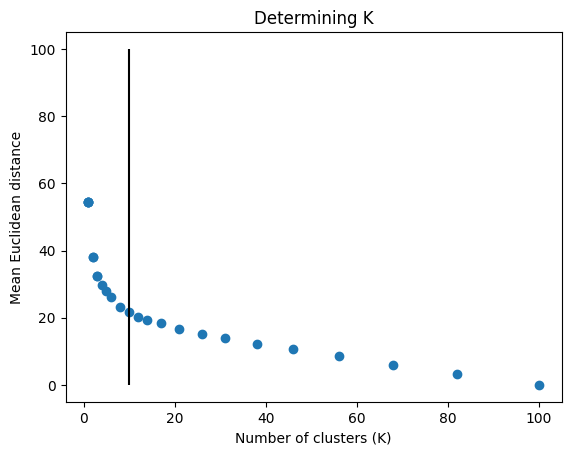

In [32]:
plt.scatter(clusters, error)
plt.vlines(10, 0, 100, color='black')
plt.title("Determining K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Mean Euclidean distance")
plt.show()

10 looks pretty good to me :)

In [19]:
centroids, distortion = kmeans(data_whitened, k_or_guess=10, seed=seed)
print(f"Distortion: {distortion:.4f}")

labels, distances = vq(data_whitened, centroids)

cluster_series = pd.Series(labels, index=data_clean.index, name='cluster_kmeans')
mosaik_cluster_labeled = mosaik_features.join(cluster_series)

print(mosaik_cluster_labeled['cluster_kmeans'].value_counts(dropna=False))
print(mosaik_cluster_labeled.shape)

Distortion: 21.5827
cluster_kmeans
0    19
6    13
1    12
7    12
8    12
9    11
2    11
4     5
3     4
5     1
Name: count, dtype: int64
(100, 4006)


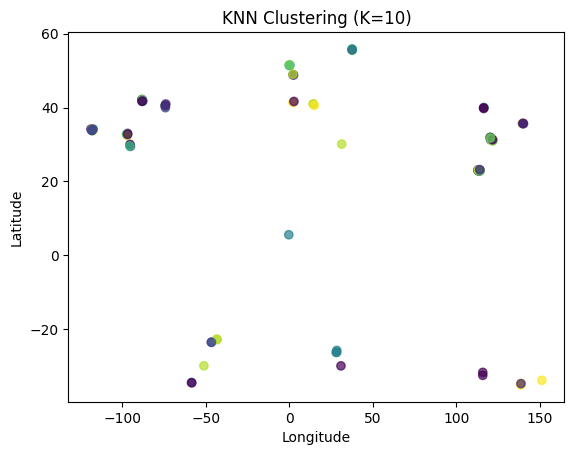

In [20]:
plt.scatter(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat'], c=mosaik_cluster_labeled['cluster_kmeans'], alpha=0.7)
plt.title("KNN Clustering (K=10)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [21]:
mosaik_cluster_labeled.to_csv("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_knn_10.csv", index=False)

In [22]:
gdf = gpd.GeoDataFrame(
    mosaik_cluster_labeled['cluster_kmeans'], 
    geometry=gpd.points_from_xy(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat']),
    crs="EPSG:4326"
)

#gdf.to_file("/data-store/iplant/home/thunr/analyses/clusters_knn.geojson", driver='GeoJSON')
gdf.to_file("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_knn_10.geojson", driver='GeoJSON')

Now we apply to entire dataset.

In [23]:
files = glob.glob("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/city_embeddings_cropped/*.parquet")

full_mosaik_features = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)

In [24]:
full_mosaik_features.shape

(84261, 4005)

In [26]:
feat_cols = [c for c in mosaik_features.columns if c.startswith('X_')]

# Drop zero-norm rows that have no cluster label
subset_valid  = mosaik_cluster_labeled.dropna(subset=['cluster_kmeans'])
subset_feat   = subset_valid[feat_cols].to_numpy()
subset_labels = subset_valid['cluster_kmeans'].to_numpy().astype(int)

# Full dataset features
full_feat = full_mosaik_features[feat_cols].to_numpy()

# Build tree and query
tree = cKDTree(subset_feat)
k = 3
distances, indices = tree.query(full_feat, k=k)

# Majority vote on neighbor labels
neighbor_labels  = subset_labels[indices]   # shape: (n_full, k)
full_labels_knn  = np.apply_along_axis(
    lambda row: np.bincount(row).argmax(),
    axis=1,
    arr=neighbor_labels
)

# Join back to full dataframe
full_mosaik_features['cluster_knn'] = full_labels_knn

In [27]:
full_mosaik_features.shape

(84261, 4006)

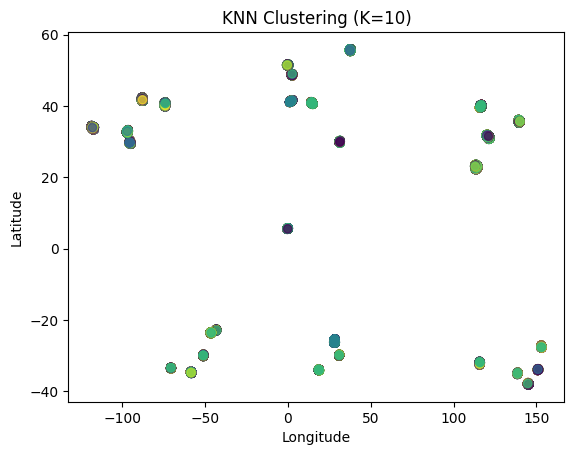

In [30]:
plt.scatter(full_mosaik_features['lon'], full_mosaik_features['lat'], c=full_mosaik_features['cluster_knn'], alpha=0.7)
plt.title("KNN Clustering (K=10)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [29]:
mosaik_cluster_labeled.to_csv("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/applied_clusters_knn_10.csv", index=False)

In [31]:
gdf = gpd.GeoDataFrame(
    full_mosaik_features['cluster_knn'], 
    geometry=gpd.points_from_xy(full_mosaik_features['lon'], full_mosaik_features['lat']),
    crs="EPSG:4326"
)

#gdf.to_file("/data-store/iplant/home/thunr/analyses/all_clusters.geojson", driver='GeoJSON')
gdf.to_file("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/applied_clusters_knn_10.geojson", driver='GeoJSON')